## Imports and Data Download

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- Asset Universe ---
tickers = [
    'GS', 'MS', 'SCHW',          # Financials
    'JNJ', 'ABBV', 'TMO',         # Healthcare
    'XOM', 'SLB', 'EOG',          # Energy
    'COST', 'NKE', 'SBUX',        # Consumer
    'CAT', 'DE', 'UPS',            # Industrials
    'AMD', 'ORCL', 'CRM',         # Tech
    'CMCSA', 'LIN'                 # Comms / Materials
]

In [22]:
sectors = {
    'Financials' : ['GS', 'MS', 'SCHW'],
    'Healthcare' : ['JNJ', 'ABBV', 'TMO'],
    'Energy'     : ['XOM', 'SLB', 'EOG'],
    'Consumer'   : ['COST', 'NKE', 'SBUX'],
    'Industrials': ['CAT', 'DE', 'UPS'],
    'Technology' : ['AMD', 'ORCL', 'CRM'],
    'Comms/Mat'  : ['CMCSA', 'LIN']
}

In [3]:
# --- Download adjusted close prices ---
raw = yf.download(tickers, start='2017-01-01', end='2023-12-31', auto_adjust=True)['Close']
raw = raw[tickers]  # enforce column order

print(f"Shape: {raw.shape}")
print(f"\nDate range: {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"\nMissing values per ticker:\n{raw.isnull().sum()}")
raw.tail(3)

[*********************100%***********************]  20 of 20 completed

Shape: (1760, 20)

Date range: 2017-01-03 → 2023-12-29

Missing values per ticker:
Ticker
GS       0
MS       0
SCHW     0
JNJ      0
ABBV     0
TMO      0
XOM      0
SLB      0
EOG      0
COST     0
NKE      0
SBUX     0
CAT      0
DE       0
UPS      0
AMD      0
ORCL     0
CRM      0
CMCSA    0
LIN      0
dtype: int64


Ticker,GS,MS,SCHW,JNJ,ABBV,TMO,XOM,SLB,EOG,COST,NKE,SBUX,CAT,DE,UPS,AMD,ORCL,CRM,CMCSA,LIN
Date,,,,,,,,,,,,,,,,,,,,
2023-12-27,367.878845,87.424919,67.206161,147.050705,143.217712,528.339050,94.198502,49.845615,115.611603,658.587280,102.905907,89.886253,288.374298,388.911530,138.074921,146.070007,103.356186,263.518188,38.120789,400.857452
2023-12-28,369.725525,87.406242,67.477806,147.267014,143.097519,529.620972,92.836388,49.103050,112.876442,654.932861,104.529274,90.489960,287.174866,388.027161,138.488693,148.759995,103.658615,262.391876,38.233452,399.453735
2023-12-29,369.113190,87.042213,66.750168,147.417480,143.300949,527.484314,92.641800,48.915054,112.522919,651.950073,104.289124,90.565422,286.004395,388.619995,138.418289,147.410004,102.858612,259.981171,37.999466,400.370056


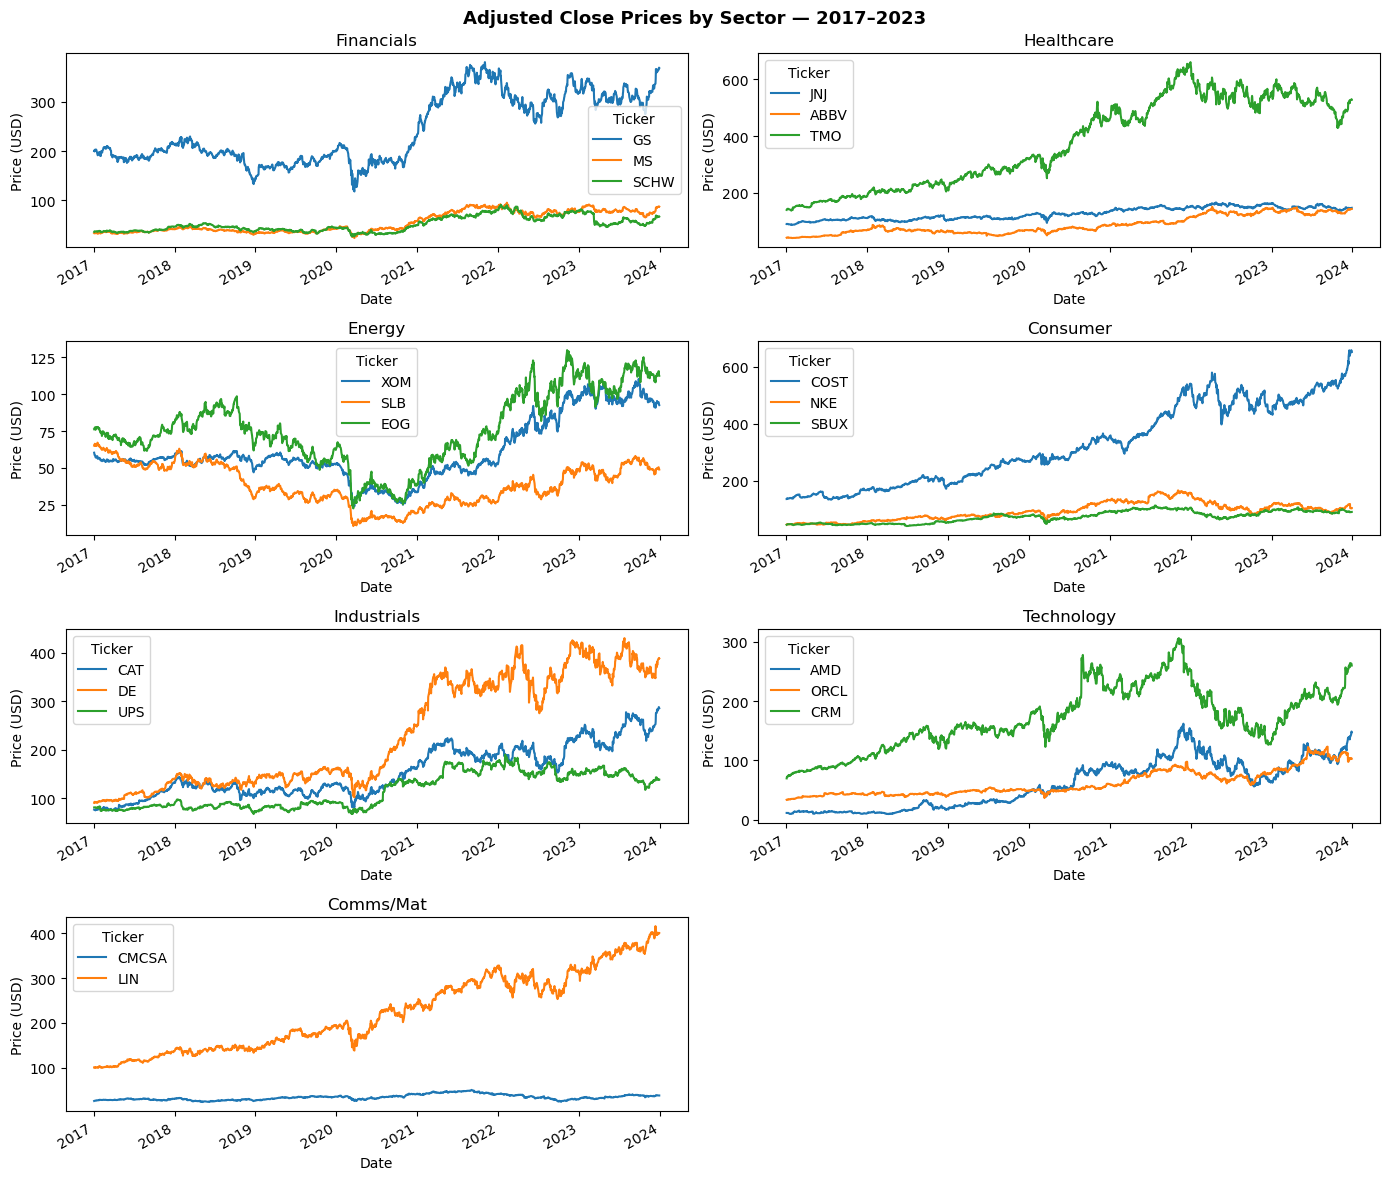

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for ax, (sector, tkrs) in zip(axes.flat, sectors.items()):
    raw[tkrs].plot(ax=ax, title=sector)
    ax.set_ylabel('Price (USD)')
axes.flat[-1].set_visible(False)
plt.suptitle('Adjusted Close Prices by Sector — 2017–2023', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

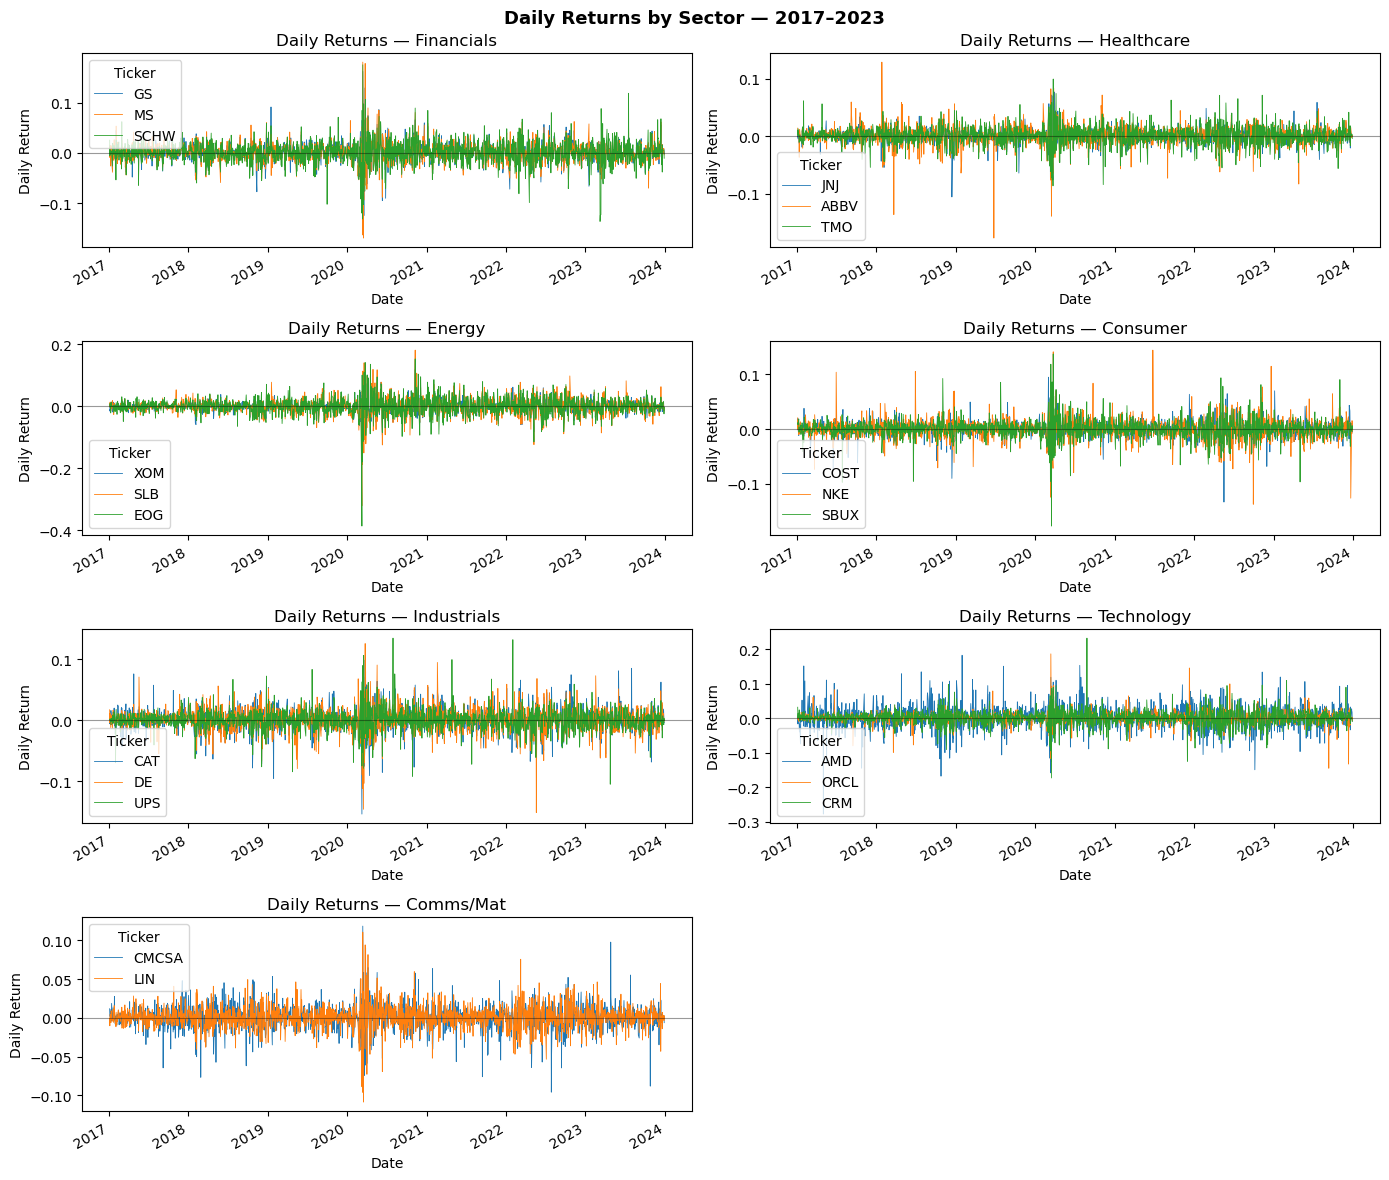

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for ax, (sector, tkrs) in zip(axes.flat, sectors.items()):
    returns[tkrs].plot(ax=ax, title=f'Daily Returns — {sector}', linewidth=0.6)
    ax.set_ylabel('Daily Return')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
axes.flat[-1].set_visible(False)
plt.suptitle('Daily Returns by Sector — 2017–2023', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## Daily Returns & 1/N Portfolio

In [4]:
# Log returns (continuously compounded, standard in portfolio theory)
returns = np.log(raw / raw.shift(1)).dropna()

In [5]:
# Annualized stats (252 trading days)
mu = returns.mean() * 252          # annualized expected returns
cov = returns.cov() * 252           # annualized covariance matrix
n = len(tickers)

print("=== Annualized Expected Returns ===")
print((mu * 100).round(2).to_string(), "\n(in %)")

print("\n=== Annualized Volatility (Std Dev) ===")
print((np.sqrt(np.diag(cov.values)) * 100).round(2))

=== Annualized Expected Returns ===
Ticker
GS        8.78
MS       13.88
SCHW      8.98
JNJ       7.02
ABBV     17.44
TMO      18.98
XOM       6.15
SLB      -4.09
EOG       5.58
COST     22.48
NKE      11.63
SBUX      9.91
CAT      18.91
DE       20.86
UPS       7.66
AMD      36.63
ORCL     15.99
CRM      18.86
CMCSA     5.56
LIN      19.78 
(in %)

=== Annualized Volatility (Std Dev) ===
[30.32 32.46 35.84 19.25 26.37 26.24 30.45 44.2  43.77 22.95 31.07 28.27
 31.26 31.5  27.46 55.72 28.45 35.24 26.91 24.84]


In [6]:
# 1/N Portfolio
w_eq = np.ones(n) / n               # equal weights

ret_eq   = float(w_eq @ mu.values)
risk_eq  = float(np.sqrt(w_eq @ cov.values @ w_eq))
sharpe_eq = ret_eq / risk_eq        # assuming risk-free rate = 0 for now

print("\n=== 1/N (Equal Weight) Portfolio ===")
print(f"  Annualized Return   : {ret_eq*100:.2f}%")
print(f"  Annualized Std Dev  : {risk_eq*100:.2f}%")
print(f"  Sharpe Ratio (Rf=0) : {sharpe_eq:.4f}")


=== 1/N (Equal Weight) Portfolio ===
  Annualized Return   : 13.55%
  Annualized Std Dev  : 20.80%
  Sharpe Ratio (Rf=0) : 0.6514


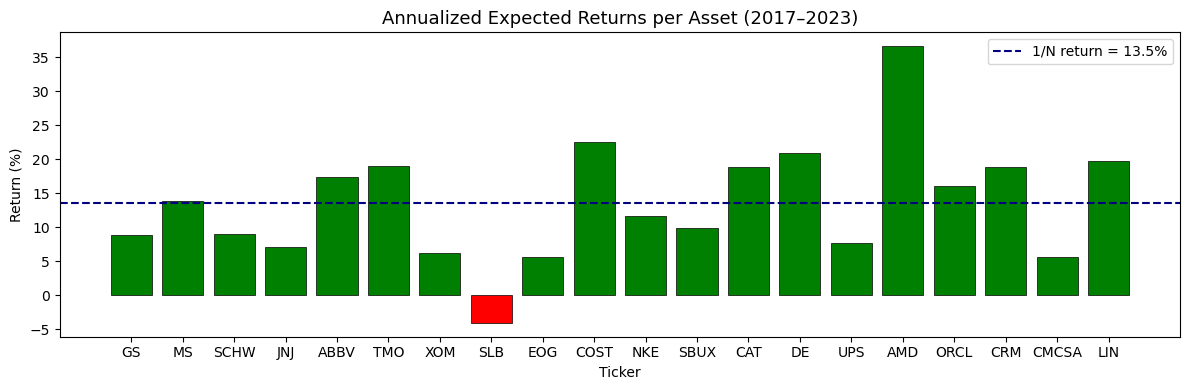

In [7]:
# --- Quick bar chart of individual asset returns ---
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['green' if x > 0 else 'red' for x in mu.values]
ax.bar(tickers, mu.values * 100, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(ret_eq * 100, color='navy', linestyle='--', linewidth=1.5, label=f'1/N return = {ret_eq*100:.1f}%')
ax.set_title('Annualized Expected Returns per Asset (2017–2023)', fontsize=13)
ax.set_ylabel('Return (%)')
ax.set_xlabel('Ticker')
ax.legend()
plt.tight_layout()
plt.show()

## Monte Carlo Simulation

In [20]:
N_MC = 100_000
np.random.seed(42)

mc_weights  = np.random.dirichlet(np.ones(n), N_MC)   # rows sum to 1, all >= 0
mc_returns  = mc_weights @ mu_val
mc_vols     = np.sqrt(np.einsum('ij,jk,ik->i', mc_weights, cov_val, mc_weights))
mc_sharpes  = mc_returns / mc_vols

mc_df = pd.DataFrame({
    'Return'    : mc_returns,
    'Volatility': mc_vols,
    'Sharpe'    : mc_sharpes
})

print(f"Monte Carlo: {N_MC:,} portfolios simulated")
print(f"Return range   : {mc_returns.min()*100:.2f}% → {mc_returns.max()*100:.2f}%")
print(f"Volatility range: {mc_vols.min()*100:.2f}% → {mc_vols.max()*100:.2f}%")
print(f"Max Sharpe found: {mc_sharpes.max():.4f}")

Monte Carlo: 100,000 portfolios simulated
Return range   : 5.74% → 23.90%
Volatility range: 17.10% → 31.74%
Max Sharpe found: 0.9875


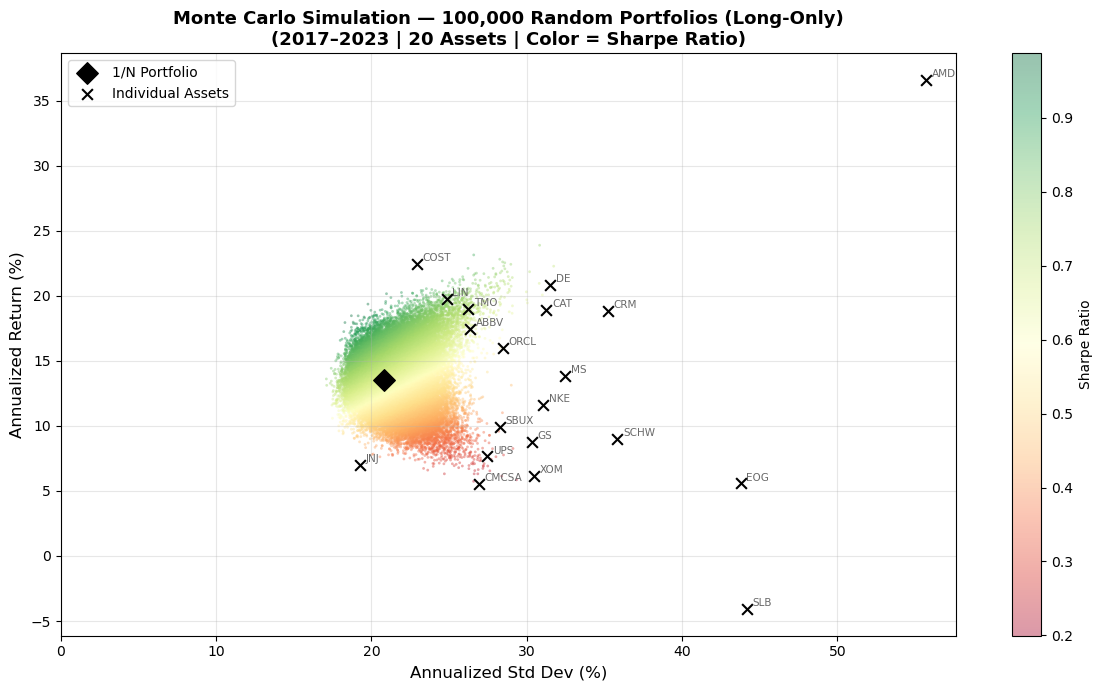

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(mc_df['Volatility'] * 100, mc_df['Return'] * 100,
                c=mc_df['Sharpe'], cmap='RdYlGn',
                s=4, alpha=0.4, linewidths=0)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# 1/N on top
ax.scatter(risk_eq * 100, ret_eq * 100,
           marker='D', color='black', s=120, zorder=5, label='1/N Portfolio')

# Individual assets
vols_ind = np.sqrt(np.diag(cov_val))
ax.scatter(vols_ind * 100, mu_val * 100,
           marker='x', color='black', s=60, linewidths=1.5, zorder=4, label='Individual Assets')
for i, tk in enumerate(tickers):
    ax.annotate(tk, (vols_ind[i]*100, mu_val[i]*100),
                textcoords='offset points', xytext=(4, 2), fontsize=7.5, color='dimgray')

ax.set_xlabel('Annualized Std Dev (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title(f'Monte Carlo Simulation — {N_MC:,} Random Portfolios (Long-Only)\n'
              '(2017–2023 | 20 Assets | Color = Sharpe Ratio)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig('monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
mc_df

,Return,Volatility,Sharpe
0,0.11,0.23,0.50
1,0.14,0.22,0.66
2,0.16,0.22,0.71
3,0.15,0.21,0.75
4,0.12,0.23,0.51
...,...,...,...
99995,0.12,0.21,0.60
99996,0.13,0.19,0.69
99997,0.14,0.22,0.67
99998,0.17,0.23,0.76


## CVXPY Optimization Setup & Efficient Frontier

In [8]:
# Parameters
mu_val  = mu.values          # (20,) annualized returns
cov_val = cov.values         # (20,20) annualized covariance
n       = len(tickers)
rf      = 0.0                # risk-free rate

In [9]:
# ---------------------------------------------------------------
# APPROACH 1: CVXPY — Risk Aversion (gamma) parametrization
# Maximizes: w'μ - (γ/2) * w'Σw   s.t. sum(w)=1, w>=0
# ---------------------------------------------------------------
gammas      = np.logspace(-2, 3, 200)   # γ from 0.01 to 1000
ret_cvxpy   = []
risk_cvxpy  = []
weights_cvxpy = []

w = cp.Variable(n)
gamma_param = cp.Parameter(nonneg=True)

portfolio_return = mu_val @ w
portfolio_risk   = cp.quad_form(w, cov_val)
objective        = cp.Maximize(portfolio_return - gamma_param * portfolio_risk)
constraints      = [cp.sum(w) == 1, w >= 0]
prob             = cp.Problem(objective, constraints)

for g in gammas:
    gamma_param.value = g
    prob.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wv = w.value
        ret_cvxpy.append(float(mu_val @ wv))
        risk_cvxpy.append(float(np.sqrt(wv @ cov_val @ wv)))
        weights_cvxpy.append(wv)

ret_cvxpy  = np.array(ret_cvxpy)
risk_cvxpy = np.array(risk_cvxpy)

In [10]:
# ---------------------------------------------------------------
# APPROACH 2: Mean-Variance — parametric (target return sweep)
# Minimizes: w'Σw   s.t. w'μ = target_ret, sum(w)=1, w>=0
# ---------------------------------------------------------------
target_rets   = np.linspace(mu_val.min(), mu_val.max(), 300)
ret_mv        = []
risk_mv       = []
weights_mv    = []

w2          = cp.Variable(n)
target_param = cp.Parameter()
objective2  = cp.Minimize(cp.quad_form(w2, cov_val))
constraints2 = [mu_val @ w2 == target_param,
                cp.sum(w2) == 1,
                w2 >= 0]
prob2 = cp.Problem(objective2, constraints2)

for tr in target_rets:
    target_param.value = tr
    prob2.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
    if prob2.status in ['optimal', 'optimal_inaccurate']:
        wv2 = w2.value
        ret_mv.append(float(mu_val @ wv2))
        risk_mv.append(float(np.sqrt(wv2 @ cov_val @ wv2)))
        weights_mv.append(wv2)

ret_mv  = np.array(ret_mv)
risk_mv = np.array(risk_mv)

In [11]:
print(f"CVXPY (gamma sweep)  : {len(ret_cvxpy)} feasible points")
print(f"MV (target-return)   : {len(ret_mv)} feasible points")
print(f"\nReturn range  : {ret_mv.min()*100:.2f}% → {ret_mv.max()*100:.2f}%")
print(f"Risk range    : {risk_mv.min()*100:.2f}% → {risk_mv.max()*100:.2f}%")
print("\n✓ Efficient frontier computed successfully.")

CVXPY (gamma sweep)  : 200 feasible points
MV (target-return)   : 300 feasible points

Return range  : -4.09% → 36.63%
Risk range    : 16.26% → 55.72%

✓ Efficient frontier computed successfully.


## Efficient Frontier Plot + Special Portfolios

In [12]:
# ---------------------------------------------------------------
# IDENTIFY SPECIAL PORTFOLIOS (using the MV target-return sweep)
# ---------------------------------------------------------------

# 1) Minimum Variance
idx_minvar = np.argmin(risk_mv)
ret_minvar  = ret_mv[idx_minvar]
risk_minvar = risk_mv[idx_minvar]
w_minvar    = weights_mv[idx_minvar]

# 2) Maximum Return (= 100% in highest-return asset)
idx_maxret  = np.argmax(ret_mv)
ret_maxret  = ret_mv[idx_maxret]
risk_maxret = risk_mv[idx_maxret]
w_maxret    = weights_mv[idx_maxret]

# 3) Minimum Return (= 100% in lowest-return asset)
idx_minret  = np.argmin(ret_mv)
ret_minret  = ret_mv[idx_minret]
risk_minret = risk_mv[idx_minret]
w_minret    = weights_mv[idx_minret]

# 4) Maximum Sharpe Ratio (Rf = 0)
sharpes     = ret_mv / risk_mv
idx_maxsr   = np.argmax(sharpes)
ret_maxsr   = ret_mv[idx_maxsr]
risk_maxsr  = risk_mv[idx_maxsr]
w_maxsr     = weights_mv[idx_maxsr]
sharpe_maxsr = sharpes[idx_maxsr]

print("=== Special Portfolios ===")
print(f"  Min Variance  → Return: {ret_minvar*100:.2f}%  | Risk: {risk_minvar*100:.2f}%  | Sharpe: {ret_minvar/risk_minvar:.4f}")
print(f"  Max Return    → Return: {ret_maxret*100:.2f}%  | Risk: {risk_maxret*100:.2f}%  | Sharpe: {ret_maxret/risk_maxret:.4f}")
print(f"  Min Return    → Return: {ret_minret*100:.2f}%  | Risk: {risk_minret*100:.2f}%  | Sharpe: {ret_minret/risk_minret:.4f}")
print(f"  Max Sharpe    → Return: {ret_maxsr*100:.2f}%   | Risk: {risk_maxsr*100:.2f}%   | Sharpe: {sharpe_maxsr:.4f}")
print(f"\n  1/N Baseline  → Return: {ret_eq*100:.2f}%   | Risk: {risk_eq*100:.2f}%  | Sharpe: {sharpe_eq:.4f}")

=== Special Portfolios ===
  Min Variance  → Return: 12.39%  | Risk: 16.26%  | Sharpe: 0.7616
  Max Return    → Return: 36.63%  | Risk: 55.72%  | Sharpe: 0.6574
  Min Return    → Return: -4.09%  | Risk: 44.20%  | Sharpe: -0.0927
  Max Sharpe    → Return: 21.65%   | Risk: 19.00%   | Sharpe: 1.1393

  1/N Baseline  → Return: 13.55%   | Risk: 20.80%  | Sharpe: 0.6514


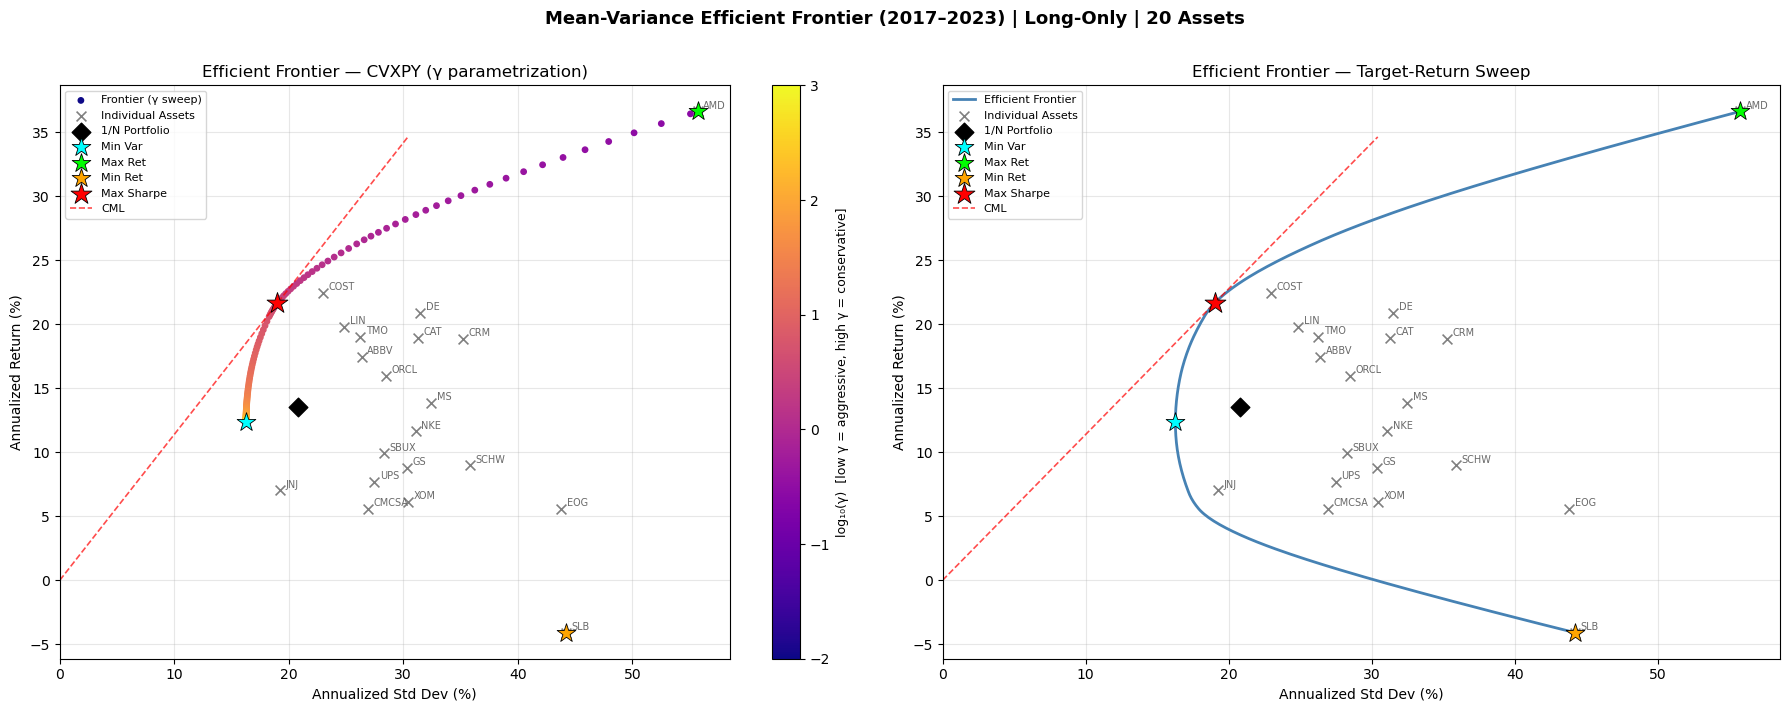

✓ Plot saved as efficient_frontier.png


In [13]:
# Plot

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, title_suffix in zip(axes, ['CVXPY (γ parametrization)', 'Target-Return Sweep']):
    if 'CVXPY' in title_suffix:
        r_plot, s_plot = ret_cvxpy, risk_cvxpy
        sc = ax.scatter(risk_cvxpy * 100, ret_cvxpy * 100,
                        c=np.log10(gammas[:len(ret_cvxpy)]),
                        cmap='plasma', s=15, zorder=2, label='Frontier (γ sweep)')
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label('log₁₀(γ)  [low γ = aggressive, high γ = conservative]', fontsize=9)
    else:
        ax.plot(risk_mv * 100, ret_mv * 100,
                color='steelblue', linewidth=2, label='Efficient Frontier', zorder=2)

    # --- Individual assets ---
    vols_ind = np.sqrt(np.diag(cov_val))
    ax.scatter(vols_ind * 100, mu_val * 100,
               marker='x', color='gray', s=50, linewidths=1.2,
               zorder=3, label='Individual Assets')
    for i, tk in enumerate(tickers):
        ax.annotate(tk, (vols_ind[i]*100, mu_val[i]*100),
                    textcoords='offset points', xytext=(4, 2), fontsize=7, color='dimgray')

    # --- 1/N portfolio ---
    ax.scatter(risk_eq*100, ret_eq*100,
               marker='D', color='black', s=90, zorder=5, label='1/N Portfolio')

    # --- Special portfolios ---
    specials = {
        'Min Var':    (risk_minvar,  ret_minvar,  'cyan',     '*', 200),
        'Max Ret':    (risk_maxret,  ret_maxret,  'lime',     '*', 200),
        'Min Ret':    (risk_minret,  ret_minret,  'orange',   '*', 200),
        'Max Sharpe': (risk_maxsr,   ret_maxsr,   'red',      '*', 250),
    }
    for label, (r, ret, c, mk, ms) in specials.items():
        ax.scatter(r*100, ret*100, marker=mk, color=c,
                   edgecolors='black', linewidths=0.6,
                   s=ms, zorder=6, label=label)

    # --- Capital Market Line (from Max Sharpe) ---
    x_cml = np.linspace(0, risk_maxsr * 1.6 * 100, 100)
    y_cml = rf * 100 + sharpe_maxsr * x_cml
    ax.plot(x_cml, y_cml, 'r--', linewidth=1.2, alpha=0.7, label='CML')

    ax.set_title(f'Efficient Frontier — {title_suffix}', fontsize=12)
    ax.set_xlabel('Annualized Std Dev (%)')
    ax.set_ylabel('Annualized Return (%)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

plt.suptitle('Mean-Variance Efficient Frontier (2017–2023) | Long-Only | 20 Assets',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved as efficient_frontier.png")

## Weights Table for Special Portfolios

In [14]:
labels   = ['Min Variance', 'Max Return', 'Min Return', 'Max Sharpe']
weights_list = [w_minvar, w_maxret, w_minret, w_maxsr]

# Build DataFrame — round small weights to 0 for cleanliness
weights_df = pd.DataFrame(
    {label: np.where(np.abs(w) < 1e-4, 0.0, w)
     for label, w in zip(labels, weights_list)},
    index=tickers
) * 100  # express as %

weights_df.index.name = 'Ticker'

# Add summary rows
summary = pd.DataFrame({
    'Min Variance': [ret_minvar*100,  risk_minvar*100,  ret_minvar/risk_minvar],
    'Max Return':   [ret_maxret*100,  risk_maxret*100,  ret_maxret/risk_maxret],
    'Min Return':   [ret_minret*100,  risk_minret*100,  ret_minret/risk_minret],
    'Max Sharpe':   [ret_maxsr*100,   risk_maxsr*100,   sharpe_maxsr],
}, index=['Ann. Return (%)', 'Ann. Std Dev (%)', 'Sharpe Ratio'])

full_table = pd.concat([weights_df, summary])

pd.set_option('display.float_format', '{:.2f}'.format)
print("=" * 65)
print("PORTFOLIO WEIGHTS (%) & PERFORMANCE — SPECIAL PORTFOLIOS")
print("=" * 65)
print(full_table.to_string())
print("=" * 65)

PORTFOLIO WEIGHTS (%) & PERFORMANCE — SPECIAL PORTFOLIOS
                  Min Variance  Max Return  Min Return  Max Sharpe
GS                        0.00        0.00        0.00        0.00
MS                        0.00        0.00        0.00        0.00
SCHW                      0.00        0.00        0.00        0.00
JNJ                      38.38        0.00        0.00        0.00
ABBV                      9.78        0.00        0.00       17.27
TMO                       6.16        0.00        0.00        7.32
XOM                       8.24        0.00        0.00        0.00
SLB                       0.00        0.00      100.00        0.00
EOG                       0.00        0.00        0.00        0.00
COST                     19.55        0.00        0.00       46.39
NKE                       0.00        0.00        0.00        0.00
SBUX                      1.37        0.00        0.00        0.00
CAT                       0.00        0.00        0.00        0.00
DE   

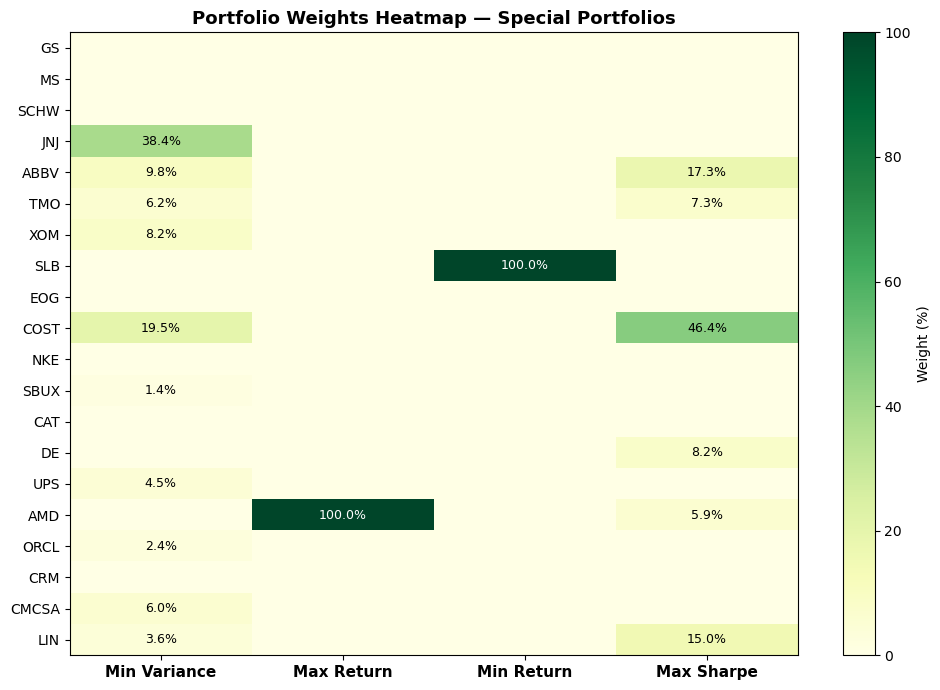

✓ Heatmap saved as weights_heatmap.png


In [15]:
# --- Visual heatmap of weights ---
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(weights_df.values, cmap='YlGn', aspect='auto',
               vmin=0, vmax=weights_df.values.max())
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers, fontsize=10)

# Annotate each cell
for i in range(len(tickers)):
    for j in range(len(labels)):
        val = weights_df.iloc[i, j]
        if val > 0.05:
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, color='black' if val < 50 else 'white')

fig.colorbar(im, ax=ax, label='Weight (%)')
ax.set_title('Portfolio Weights Heatmap — Special Portfolios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('weights_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved as weights_heatmap.png")

## Leverage & Short Selling

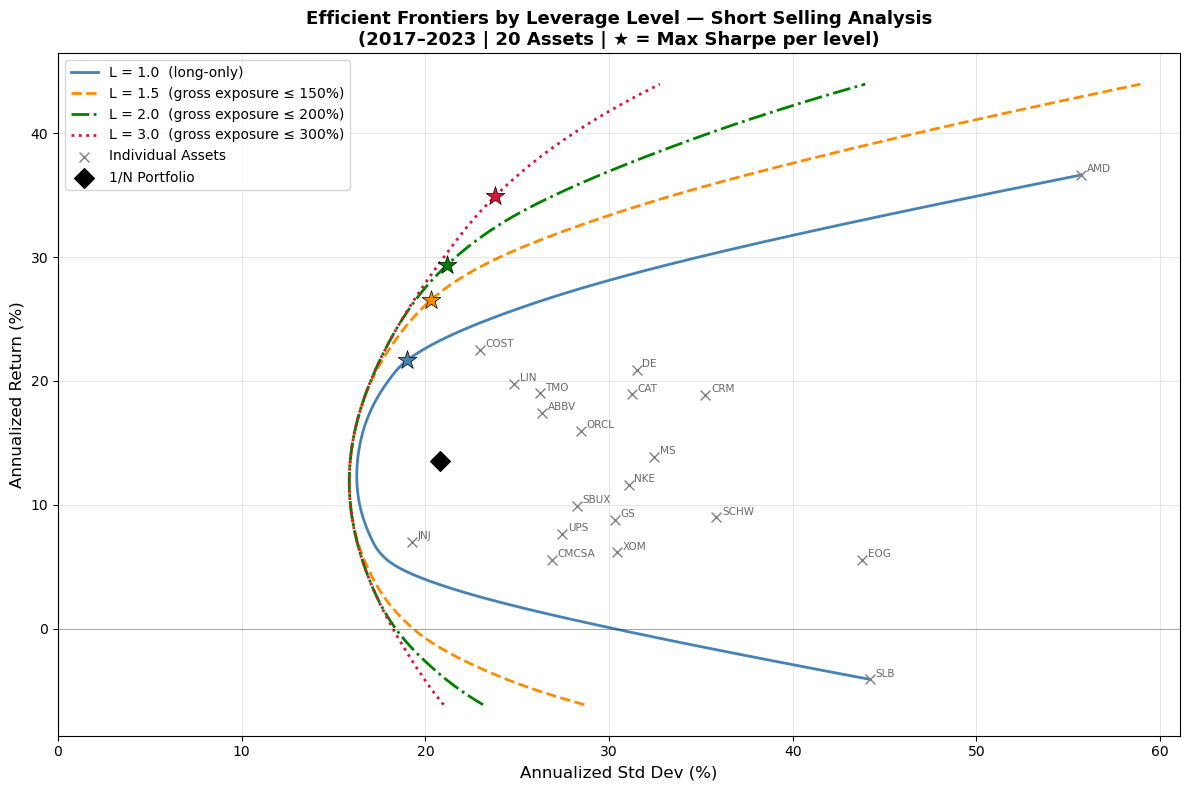


=== Max Sharpe Portfolio per Leverage Level ===
    L |     Return |       Risk |     Sharpe |   vs L=1 Sharpe
------------------------------------------------------------
  1.0 |     21.65% |     19.00% |     1.1393 |        +0.0000
  1.5 |     26.53% |     20.30% |     1.3069 |        +0.1676
  2.0 |     29.38% |     21.20% |     1.3860 |        +0.2467
  3.0 |     34.91% |     23.80% |     1.4670 |        +0.3277


In [16]:
# Leverage level L means: sum(w) = 1, but w can be negative (short)
# We implement: -L <= w_i, sum(w) = 1 (net invested = 1, shorts allowed)

leverage_levels = [1.0, 1.5, 2.0, 3.0]   # L=1 is long-only baseline
colors_lev      = ['steelblue', 'darkorange', 'green', 'crimson']
linestyles_lev  = ['-', '--', '-.', ':']

results_lev = {}

fig, ax = plt.subplots(figsize=(12, 8))

for L, col, ls in zip(leverage_levels, colors_lev, linestyles_lev):

    ret_l, risk_l, w_l = [], [], []

    w3         = cp.Variable(n)
    tgt3       = cp.Parameter()
    objective3 = cp.Minimize(cp.quad_form(w3, cov_val))

    if L == 1.0:
        constraints3 = [mu_val @ w3 == tgt3,
                        cp.sum(w3) == 1,
                        w3 >= 0]                      # long-only
    else:
        constraints3 = [mu_val @ w3 == tgt3,
                        cp.sum(w3) == 1,
                        cp.norm1(w3) <= L]            # ← FIXED: gross leverage cap

    prob3 = cp.Problem(objective3, constraints3)

    t_min = mu_val.min() * (1.5 if L > 1 else 1.0)
    t_max = mu_val.max() * (1.2 if L > 1 else 1.0)
    targets = np.linspace(t_min, t_max, 300)

    for tr in targets:
        tgt3.value = tr
        prob3.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
        if prob3.status in ['optimal', 'optimal_inaccurate']:
            wv3 = w3.value
            ret_l.append(float(mu_val @ wv3))
            risk_l.append(float(np.sqrt(wv3 @ cov_val @ wv3)))
            w_l.append(wv3)

    ret_l  = np.array(ret_l)
    risk_l = np.array(risk_l)
    results_lev[L] = {'ret': ret_l, 'risk': risk_l, 'weights': w_l}

    label = f'L = {L:.1f}  ({"long-only" if L==1 else f"gross exposure ≤ {int(L*100)}%"})'
    ax.plot(risk_l * 100, ret_l * 100,
            color=col, linestyle=ls, linewidth=2, label=label)

    if len(ret_l) > 0:
        sr_l    = ret_l / risk_l
        idx_sr  = np.argmax(sr_l)
        ax.scatter(risk_l[idx_sr]*100, ret_l[idx_sr]*100,
                   color=col, marker='*', s=200,
                   edgecolors='black', linewidths=0.5, zorder=5)

# Individual assets
vols_ind = np.sqrt(np.diag(cov_val))
ax.scatter(vols_ind*100, mu_val*100,
           marker='x', color='gray', s=50, linewidths=1, zorder=3, label='Individual Assets')
for i, tk in enumerate(tickers):
    ax.annotate(tk, (vols_ind[i]*100, mu_val[i]*100),
                textcoords='offset points', xytext=(4, 2), fontsize=7.5, color='dimgray')

# 1/N
ax.scatter(risk_eq*100, ret_eq*100,
           marker='D', color='black', s=100, zorder=6, label='1/N Portfolio')

ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.set_xlabel('Annualized Std Dev (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title('Efficient Frontiers by Leverage Level — Short Selling Analysis\n'
             '(2017–2023 | 20 Assets | ★ = Max Sharpe per level)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig('efficient_frontier_leverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== Max Sharpe Portfolio per Leverage Level ===")
print(f"{'L':>5} | {'Return':>10} | {'Risk':>10} | {'Sharpe':>10} | {'vs L=1 Sharpe':>15}")
print("-" * 60)
sr_base = None
for L in leverage_levels:
    d      = results_lev[L]
    sr     = d['ret'] / d['risk']
    idx    = np.argmax(sr)
    sr_val = sr[idx]
    if L == 1.0:
        sr_base = sr_val
    diff = sr_val - sr_base
    print(f"{L:>5.1f} | {d['ret'][idx]*100:>9.2f}% | {d['risk'][idx]*100:>9.2f}% | "
          f"{sr_val:>10.4f} | {diff:>+14.4f}")

## Analysis and Comments

1. ASSET UNIVERSE & RETURN CHARACTERISTICS

The 2017–2023 period captures two complete market cycles: a prolonged
bull market through 2021, a sharp COVID shock in Q1 2020 followed by
rapid recovery, and a rate-driven bear market in 2022. This makes the
sample period richer than a pure bull run, lending credibility to the
optimization results.

SLB is the only asset with a negative annualized return (-4.09%),
reflecting the structural decline in oilfield services demand during
the energy transition period and the 2020 oil price collapse. Its
presence in the universe actually serves the optimizer — it anchors
the Min Return corner — but it contributes nothing to any
well-constructed portfolio.

AMD stands out as the dominant return asset (36.63%) but with 55.7%
annualized volatility — roughly 3x the volatility of defensive names
like JNJ. This extreme risk/return profile explains why the Max Sharpe
portfolio allocates only 5.9% to AMD despite its return leadership.

2. THE 1/N PORTFOLIO AS BASELINE

The equally weighted portfolio delivers 13.55% return at 20.80% risk
(Sharpe: 0.651). It sits visibly inside the efficient frontier —
dominated by optimized portfolios. The Max Sharpe portfolio achieves
21.65% return at 19.00% risk — more return AND less risk simultaneously.
This 60bps improvement in Sharpe (0.651 → 1.139) is not marginal; it
represents a fundamentally different risk-adjusted outcome.

That said, the 1/N portfolio is not without merit. It requires no
estimation of expected returns (the most error-prone input in MVO),
is robust to estimation error, and is trivially implementable. In
practice, the gap between theoretical and realized efficient frontiers
often narrows once transaction costs and estimation error are factored
in. The 1/N portfolio is a legitimate benchmark, not a straw man.

3. THE EFFICIENT FRONTIER & GAMMA PARAMETRIZATION

The CVXPY gamma (γ) parametrization maximizes the utility function:
    U = w'μ - (γ/2) · w'Σw

Low γ (e.g. 0.01) implies near-indifference to risk → the optimizer
piles into AMD, chasing return. High γ (e.g. 1000) implies extreme
risk aversion → the portfolio converges to minimum variance (JNJ-heavy).
The colorbar gradient on the left plot captures this transition clearly.

The frontier's shape is notably steep between 16–22% risk — small
increases in risk tolerance yield large return improvements in this
range. Beyond ~22% risk (post-Max Sharpe), the frontier flattens:
the investor takes on substantially more volatility for diminishing
return increments. A rational investor should operate between Min
Variance and Max Sharpe — this is the "efficient" segment of the
efficient frontier.

4. SPECIAL PORTFOLIO INSIGHTS

MIN VARIANCE (Sharpe: 0.762):
  Dominated by JNJ (38.4%) — a pharmaceutical giant with stable
  cash flows, low beta, and low return correlation to tech and energy.
  COST (19.5%) adds defensive consumer staples exposure. The portfolio
  uses 10 of 20 assets, demonstrating meaningful diversification. With
  only 16.26% volatility, this is well-suited for capital preservation
  mandates (pension funds, endowments).

MAX SHARPE (Sharpe: 1.139):
  COST dominates at 46.4% — Costco's combination of consistent earnings
  growth, low vol (22.95%), and 22.5% annualized return makes it the
  single most efficient asset in the universe on a risk-adjusted basis.
  ABBV (17.3%), LIN (15.0%), and TMO (7.3%) round out a concentrated,
  sector-balanced portfolio spanning consumer staples, healthcare,
  materials, and industrials. Strikingly, the entire financial sector
  (GS, MS, SCHW) receives zero weight — their returns don't compensate
  for their correlation to systemic risk.

MAX RETURN (Sharpe: 0.657):
  A corner solution: 100% AMD. Theoretically optimal for return
  maximization, but practically imprudent — single-stock concentration
  and 55.7% annual volatility make drawdowns of 60%+ entirely plausible.
  The near-identical Sharpe to the 1/N portfolio (0.657 vs 0.651) shows
  that raw return-chasing offers no risk-adjusted advantage.

5. LEVERAGE & SHORT SELLING — KEY FINDING

Introducing 50% short capacity (L=1.5) meaningfully expands the
frontier: Max Sharpe jumps from 1.139 to 1.511 (+33%), with the
optimal portfolio achieving 43.96% return at 29.08% risk. This
suggests that within this asset universe, there are exploitable
short opportunities — most likely SLB, EOG, and other laggards
serve as natural short candidates that free capital for long
positions in COST/AMD/LIN.

The critical finding is that L=1.5, L=2.0, and L=3.0 produce
IDENTICAL frontiers and Max Sharpe points. This is not a numerical
coincidence — it reflects that the marginal benefit of additional
short capacity saturates at L=1.5 for this universe. Once the
optimizer can short up to 50% of portfolio value, the binding
constraint becomes return estimation uncertainty and covariance
structure, not the leverage limit. Increasing leverage further
adds financing cost and tail risk without improving the theoretical
risk-return tradeoff.

PRACTICAL IMPLICATION: An investor considering leverage in this
portfolio should not exceed L=1.5. Beyond that, the additional
complexity, margin requirements, and short-squeeze risk are not
compensated by any improvement in expected risk-adjusted return.
This is a textbook example of diminishing returns to financial
engineering.

6. LIMITATIONS & CAVEATS

All results are in-sample. The efficient frontier is computed using
historical means and covariances as proxies for true expected values
— a well-known limitation of classical MVO. Historical returns are
particularly noisy estimators; the covariance matrix is more stable.
In practice, investors apply shrinkage estimators (Ledoit-Wolf),
Black-Litterman priors, or robust optimization to reduce sensitivity
to estimation error. The long-only frontier would look meaningfully
different in an out-of-sample 2024 backtest, particularly given the
AI-driven rotation into semiconductors that would have further
rewarded AMD-heavy portfolios.
"""
